# Image Inpainting via the Laplace Equation & SOR

> **Goal:** Reconstruct artificially damaged pixels by solving the discrete Laplace equation with the Successive Over-Relaxation (SOR) iterative solver.

This notebook is self-contained: it builds the complete mathematical theory — from general matrix splittings through convergence analysis, Jacobi, Gauss-Seidel, and finally SOR — before connecting that theory to the image-inpainting implementation.

---
**Outline**
1. Mathematical foundation: matrix splitting $A = M - N$
2. Convergence analysis ($k \to \infty$)
3. Canonical decomposition $A = D - L - U$
4. Jacobi method
5. Gauss-Seidel method
6. SOR — full derivation
7. Eigenvalue condition & optimal $\omega$
8. Application: discrete Laplace inpainting


---
## Part I — Mathematical Theory of Stationary Iterative Solvers

---
### 1. The Linear System

Discretising the Laplace PDE over the unknown (damaged) pixel region yields a large, sparse linear system

$$A\,\mathbf{u} = \mathbf{b}, \qquad A \in \mathbb{R}^{N \times N},$$

where $N$ = number of unknown pixels, $A$ encodes the finite-difference stencil, and $\mathbf{b}$ incorporates the known boundary values.  
Direct solvers (Gaussian elimination, LU) cost $O(N^3)$ — prohibitive for large images. **Iterative methods** exploit sparsity and cost only $O(N)$ per iteration.

---
### 2. General Matrix Splitting: $A = M - N$

The core idea is to **split** $A$ into two matrices:

$$\boxed{A = M - N}$$

where $M$ is chosen such that
- $M$ is **non-singular** (invertible), and
- systems $M\mathbf{x} = \mathbf{r}$ are **cheap to solve** (e.g., $M$ is diagonal or triangular).

Substituting into $A\mathbf{u} = \mathbf{b}$:

$$(M - N)\mathbf{u} = \mathbf{b}$$

$$M\mathbf{u} = N\mathbf{u} + \mathbf{b}$$

$$\mathbf{u} = \underbrace{M^{-1}N}_{\displaystyle T}\,\mathbf{u} + \underbrace{M^{-1}\mathbf{b}}_{\displaystyle \mathbf{c}}$$

This is a **fixed-point equation** $\mathbf{u} = T\mathbf{u} + \mathbf{c}$, which suggests the iteration:

$$\boxed{\mathbf{u}^{(k+1)} = T\,\mathbf{u}^{(k)} + \mathbf{c}, \qquad k = 0, 1, 2, \ldots}$$

$T = M^{-1}N$ is called the **iteration matrix**. Different choices of $M$ give different methods.

---
### 3. Convergence Analysis: $k \to \infty$

#### 3.1 Error Propagation

Let $\mathbf{u}^*$ be the exact solution and define the **error** at step $k$:

$$\mathbf{e}^{(k)} = \mathbf{u}^* - \mathbf{u}^{(k)}.$$

Since $\mathbf{u}^*$ satisfies the fixed-point equation exactly:

$$\mathbf{u}^* = T\mathbf{u}^* + \mathbf{c}.$$

Subtracting the iteration from this:

$$\mathbf{e}^{(k+1)} = \mathbf{u}^* - \mathbf{u}^{(k+1)} = T\mathbf{u}^* + \mathbf{c} - T\mathbf{u}^{(k)} - \mathbf{c} = T\,\mathbf{e}^{(k)}.$$

By induction over $k$ steps:

$$\mathbf{e}^{(k)} = T^k\,\mathbf{e}^{(0)}.$$

The method converges for **any** initial guess $\mathbf{u}^{(0)}$ if and only if $T^k \to 0$ as $k \to \infty$.

#### 3.2 The Spectral Radius Criterion

**Theorem.** $T^k \to 0$ as $k \to \infty$ if and only if the **spectral radius**

$$\rho(T) = \max_i |\lambda_i(T)| < 1.$$

**Proof sketch.** Assume $T$ is diagonalisable: $T = V\Lambda V^{-1}$, so $T^k = V\Lambda^k V^{-1}$. Each diagonal entry of $\Lambda^k$ is $\lambda_i^k$. This tends to zero iff $|\lambda_i| < 1$ for every $i$, i.e., $\rho(T) < 1$. $\square$

#### 3.3 Rate of Convergence

Taking norms:

$$\|\mathbf{e}^{(k)}\| = \|T^k \mathbf{e}^{(0)}\| \leq \|T^k\| \cdot \|\mathbf{e}^{(0)}\|.$$

For large $k$, $\|T^k\|^{1/k} \to \rho(T)$, so:

$$\|\mathbf{e}^{(k)}\| \sim C \cdot \rho(T)^k.$$

The error decays **geometrically** at rate $\rho(T)$.  
> **Key takeaway:** The entire engineering challenge is to design $M$ (the splitting) so that $\rho(T)$ is as small as possible.

---
### 4. Canonical Decomposition: $A = D - L - U$

For a matrix $A$ we define the structural decomposition:

$$A = D - L - U$$

| Symbol | Definition |
|--------|------------|
| $D$ | Diagonal matrix: $D_{ii} = a_{ii}$, zeros elsewhere |
| $-L$ | Strict lower-triangular part of $A$ ($L$ holds the negated sub-diagonal entries) |
| $-U$ | Strict upper-triangular part of $A$ ($U$ holds the negated super-diagonal entries) |

> **Important:** This is *not* the $LU$ factorisation — it is a simple structural split. All of Jacobi, Gauss-Seidel, and SOR are built from $D$, $L$, and $U$.

---
### 5. Jacobi Method

**Splitting:** $M_J = D$, $N_J = L + U$.

Isolate the diagonal term in the $i$-th equation of $A\mathbf{u} = \mathbf{b}$:

$$a_{ii}\,u_i + \sum_{j \neq i} a_{ij}\,u_j = b_i.$$

Solving for $u_i$ and lagging *all* off-diagonal terms to the previous iterate:

$$u_i^{(k+1)} = \frac{1}{a_{ii}}\!\left(b_i - \sum_{j \neq i} a_{ij}\,u_j^{(k)}\right).$$

Iteration matrix: $T_J = D^{-1}(L + U)$.  
Drawback: each update ignores the already-computed new values within the same sweep.

---
### 6. Gauss-Seidel Method

**Splitting:** $M_{GS} = D - L$, $N_{GS} = U$.

**Key insight over Jacobi:** Once $u_1^{(k+1)}, \ldots, u_{i-1}^{(k+1)}$ have been computed, use them *immediately* rather than discarding them:

$$\boxed{u_i^{(k+1)} = \frac{1}{a_{ii}}\!\left(b_i - \sum_{j < i} a_{ij}\,u_j^{(k+1)} - \sum_{j > i} a_{ij}\,u_j^{(k)}\right)}$$

In matrix form, multiply out $(D - L)\mathbf{u}^{(k+1)} = U\mathbf{u}^{(k)} + \mathbf{b}$ to get:

$$\mathbf{u}^{(k+1)} = (D - L)^{-1}\!\left[U\,\mathbf{u}^{(k)} + \mathbf{b}\right].$$

Iteration matrix: $T_{GS} = (D-L)^{-1}U$.

For the Laplace equation it can be shown that $\rho(T_{GS}) = \rho(T_J)^2$, meaning **Gauss-Seidel converges in roughly half the iterations of Jacobi**. But can we do even better?

---
### 7. Successive Over-Relaxation (SOR) — Full Derivation

#### 7.1 Motivation: Extrapolation Beyond Gauss-Seidel

The Gauss-Seidel update produces an estimate $\tilde{u}_i^{(k+1)}$. The **correction** it applies is:

$$\delta_i^{(k)} = \tilde{u}_i^{(k+1)} - u_i^{(k)}.$$

We know the iteration is converging, so $\delta_i^{(k)}$ points *toward* the solution. The natural question is: **what if we overshoot slightly in that direction?**

#### 7.2 The SOR Update Rule

Introduce a scalar **relaxation parameter** $\omega > 0$ and scale the correction:

$$u_i^{(k+1)} = u_i^{(k)} + \omega\,\delta_i^{(k)} = (1-\omega)\,u_i^{(k)} + \omega\,\tilde{u}_i^{(k+1)}.$$

Expanding $\tilde{u}_i^{(k+1)}$ explicitly:

$$\boxed{
u_i^{(k+1)} = (1-\omega)\,u_i^{(k)}
+ \frac{\omega}{a_{ii}}\!\left(b_i - \sum_{j<i} a_{ij}\,u_j^{(k+1)} - \sum_{j>i} a_{ij}\,u_j^{(k)}\right)
}$$

**Interpretation of $\omega$:**

| Value | Name | Effect |
|-------|------|--------|
| $\omega = 1$ | Gauss-Seidel | No modification — pure GS |
| $\omega \in (0,1)$ | Under-relaxation | Damps oscillations; useful when GS diverges |
| $\omega \in (1,2)$ | **Over-relaxation** | Overshoots GS step; **accelerates convergence** |

#### 7.3 Matrix Form of SOR

Rearranging the SOR update:

$$(D - \omega L)\,\mathbf{u}^{(k+1)} = \left[(1-\omega)D + \omega U\right]\mathbf{u}^{(k)} + \omega\,\mathbf{b}.$$

This corresponds to the splitting $A = M_\omega - N_\omega$ with:

$$M_\omega = \frac{1}{\omega}(D - \omega L), \qquad N_\omega = \frac{1}{\omega}\!\left[(1-\omega)D + \omega U\right].$$

The **SOR iteration matrix** is therefore:

$$\boxed{T_\omega = (D - \omega L)^{-1}\!\left[(1-\omega)D + \omega U\right]}$$

Verify: setting $\omega = 1$ gives $T_1 = (D-L)^{-1}U = T_{GS}$. ✓

---
### 8. Convergence of SOR: The Eigenvalue Condition

#### 8.1 The Spectral Radius Must Be Below One

From the general theory (Section 3), SOR converges iff $\rho(T_\omega) < 1$. The question is: for which $\omega$ is this achievable?

#### 8.2 Necessary Condition: $0 < \omega < 2$ (Kahan's Theorem, 1958)

**Theorem (Kahan).** A necessary condition for SOR to converge is $\omega \in (0, 2)$.

**Proof.** Compute the determinant of $T_\omega$. Using the matrix-determinant property $\det(M_\omega^{-1}N_\omega) = \det(N_\omega)/\det(M_\omega)$:

$$\det(T_\omega) = \frac{\det\!\left[(1-\omega)D + \omega U\right]}{\det(D - \omega L)}.$$

Both $(D - \omega L)$ and $\left[(1-\omega)D + \omega U\right]$ are triangular matrices (lower and upper respectively), so their determinants are products of diagonal entries:

$$\det(D - \omega L) = \prod_{i=1}^{N} a_{ii}, \qquad \det\!\left[(1-\omega)D + \omega U\right] = \prod_{i=1}^{N} (1-\omega)\,a_{ii}.$$

Therefore:

$$\det(T_\omega) = \prod_{i=1}^{N} \frac{(1-\omega)\,a_{ii}}{a_{ii}} = (1-\omega)^N.$$

But $\det(T_\omega) = \prod_{i=1}^{N} \lambda_i(T_\omega)$, so:

$$\prod_{i=1}^{N} |\lambda_i(T_\omega)| = |1-\omega|^N.$$

For convergence we need $\rho(T_\omega) < 1$, which requires every $|\lambda_i| < 1$, hence their product satisfies:

$$|1-\omega|^N = \prod |\lambda_i| \leq \rho(T_\omega)^N < 1 \implies |1 - \omega| < 1.$$

Solving $|1 - \omega| < 1$:

$$-1 < 1 - \omega < 1 \implies \boxed{0 < \omega < 2.} \qquad \square$$

> **Critical take-away:** No matter how well-conditioned the problem is, SOR *cannot possibly converge* for $\omega \leq 0$ or $\omega \geq 2$. This is a hard boundary, not a guideline.

#### 8.3 Sufficient Condition

**Theorem (Ostrowski–Reich).** If $A$ is **symmetric positive definite (SPD)**, then SOR converges for *all* $\omega \in (0, 2)$.

The 2D discrete Laplacian is SPD (positive diagonal, diagonally dominant, symmetric), so SOR is **guaranteed** to converge for any $\omega \in (0, 2)$ in our inpainting application.

#### 8.4 Optimal Relaxation Parameter $\omega^*$

Simply knowing $\omega \in (0,2)$ works is not enough — we want the $\omega$ that minimises $\rho(T_\omega)$.

For a 2D grid of size $n \times n$ with the standard 5-point Laplacian stencil, the spectral radius of the Jacobi iteration matrix is:

$$\rho_J = \cos\!\left(\frac{\pi}{n+1}\right) \approx 1 - \frac{\pi^2}{2(n+1)^2} \quad (\text{large } n).$$

**Young's formula (1954)** gives the optimal $\omega$:

$$\boxed{\omega^* = \frac{2}{1 + \sqrt{1 - \rho_J^2}}}$$

with corresponding optimal spectral radius:

$$\rho(T_{\omega^*}) = \omega^* - 1.$$

For large $n$ (as in image grids), $\rho_J \approx 1$ and $\omega^* \approx 2 - \frac{2\pi}{n+1}$, which approaches $2$ from below as the grid refines.

#### 8.5 Comparison of Convergence Rates

| Method | $\rho(T)$ (large $n$) | Iterations to $\|e\| < 10^{-6}$ |
|--------|----------------------|----------------------------------|
| Jacobi | $1 - \dfrac{\pi^2}{2n^2}$ | $O(n^2)$ |
| Gauss-Seidel | $\rho_J^2 \approx 1 - \dfrac{\pi^2}{n^2}$ | $O(n^2)$ (half of Jacobi) |
| SOR ($\omega^*$) | $1 - \dfrac{2\pi}{n}$ | $\mathbf{O(n)}$ — one order faster! |

Optimal SOR reduces the **asymptotic iteration count from $O(n^2)$ to $O(n)$** — a factor of $n$ improvement for an $n \times n$ image patch.

---


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
plt.style.use("seaborn-v0_8")

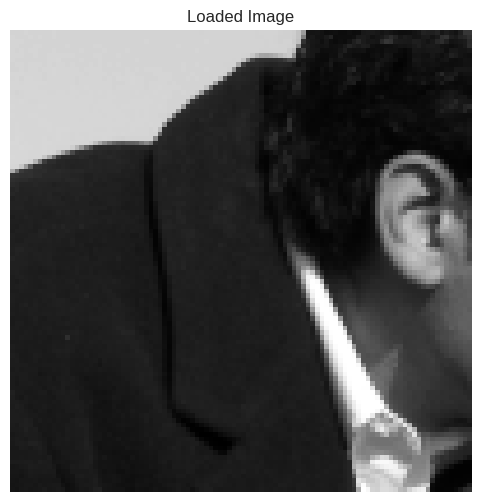

In [2]:
image_path = "./image.txt"

img = np.loadtxt(image_path).astype(float)

plt.figure(figsize=(6,6))
plt.imshow(img, cmap="gray")
plt.title("Loaded Image")
plt.axis("off")
plt.show()

## Step 1: Create Artificial Damage (Mask)
A rectangular region is removed to simulate missing pixels.


In [3]:
'''mask = np.zeros_like(img)

h, w = img.shape

# Rectangle region (adjust if needed)
mask[int(0.6*h):int(0.8*h), int(0.5*w):int(0.8*w)] = 1

plt.figure(figsize=(6,6))
plt.imshow(mask, cmap="gray")
plt.title("Binary Mask (1 = Damaged)")
plt.axis("off")
plt.show()'''


'mask = np.zeros_like(img)\n\nh, w = img.shape\n\n# Rectangle region (adjust if needed)\nmask[int(0.6*h):int(0.8*h), int(0.5*w):int(0.8*w)] = 1\n\nplt.figure(figsize=(6,6))\nplt.imshow(mask, cmap="gray")\nplt.title("Binary Mask (1 = Damaged)")\nplt.axis("off")\nplt.show()'

In [4]:
'''damaged = img.copy()
damaged[mask == 1] = 0

plt.figure(figsize=(6,6))
plt.imshow(damaged, cmap="gray")
plt.title("Damaged Image")
plt.axis("off")
plt.show()'''


'damaged = img.copy()\ndamaged[mask == 1] = 0\n\nplt.figure(figsize=(6,6))\nplt.imshow(damaged, cmap="gray")\nplt.title("Damaged Image")\nplt.axis("off")\nplt.show()'

In [5]:
'''def create_diagonal_scratch_mask(shape, thickness=2):
    """
    Creates a thin diagonal scratch mask.

    Parameters:
        shape: (height, width)
        thickness: width of the scratch line

    Returns:
        mask (numpy array)
    """
    h, w = shape
    mask = np.zeros((h, w))

    for i in range(h):
        # Diagonal line equation: j = slope * i
        j = int((w / h) * i)

        for t in range(-thickness, thickness + 1):
            if 0 <= j + t < w:
                mask[i, j + t] = 1

    return mask'''

'def create_diagonal_scratch_mask(shape, thickness=2):\n    """\n    Creates a thin diagonal scratch mask.\n\n    Parameters:\n        shape: (height, width)\n        thickness: width of the scratch line\n\n    Returns:\n        mask (numpy array)\n    """\n    h, w = shape\n    mask = np.zeros((h, w))\n\n    for i in range(h):\n        # Diagonal line equation: j = slope * i\n        j = int((w / h) * i)\n\n        for t in range(-thickness, thickness + 1):\n            if 0 <= j + t < w:\n                mask[i, j + t] = 1\n\n    return mask'

In [6]:
'''mask = create_diagonal_scratch_mask(img.shape, thickness=2)

plt.figure(figsize=(6,6))
plt.imshow(mask, cmap="gray")
plt.title("Thin Diagonal Scratch Mask")
plt.axis("off")
plt.show()'''

'mask = create_diagonal_scratch_mask(img.shape, thickness=2)\n\nplt.figure(figsize=(6,6))\nplt.imshow(mask, cmap="gray")\nplt.title("Thin Diagonal Scratch Mask")\nplt.axis("off")\nplt.show()'

In [7]:
def create_multiple_diagonal_scratches(shape,
                                       num_scratches=3,
                                       thickness=2,
                                       randomize=True,
                                       seed=42):
    """
    Creates multiple thin diagonal scratches.

    Parameters:
        shape: (height, width)
        num_scratches: number of diagonal scratches
        thickness: line thickness
        randomize: random slope & offset
        seed: random seed for reproducibility

    Returns:
        mask (numpy array)
    """
    np.random.seed(seed)

    h, w = shape
    mask = np.zeros((h, w))

    for _ in range(num_scratches):

        if randomize:
            slope = np.random.uniform(-1.5, 1.5)
            offset = np.random.randint(-h//2, h//2)
        else:
            slope = w / h
            offset = 0

        for i in range(h):
            j = int(slope * i + offset)

            for t in range(-thickness, thickness + 1):
                if 0 <= j + t < w:
                    mask[i, j + t] = 1

    return mask

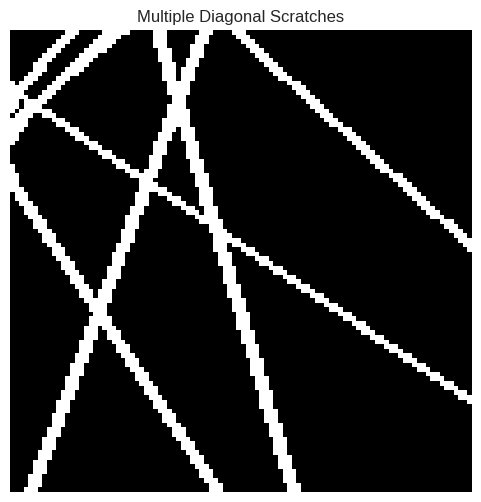

In [8]:
mask = create_multiple_diagonal_scratches(
    img.shape,
    num_scratches=10,
    thickness=1
)

plt.figure(figsize=(6,6))
plt.imshow(mask, cmap="gray")
plt.title("Multiple Diagonal Scratches")
plt.axis("off")
plt.show()

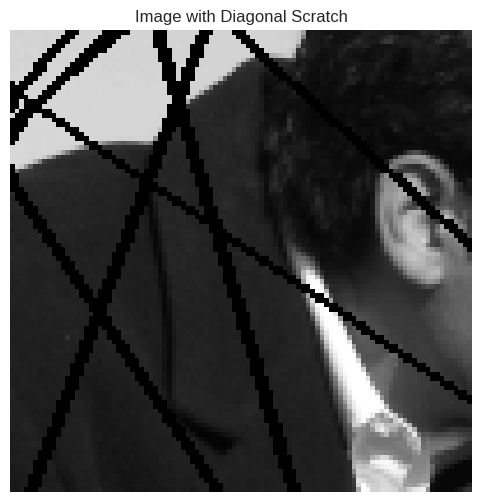

In [9]:
damaged = img.copy()
damaged[mask == 1] = 0

plt.figure(figsize=(6,6))
plt.imshow(damaged, cmap="gray")
plt.title("Image with Diagonal Scratch")
plt.axis("off")
plt.show()

---
## Part II — Applying SOR to Image Inpainting

---
### Step 2: Connecting Theory to the Discrete Laplace Equation

#### 2.1 Why the Laplace Equation?

We want to fill the missing pixels with values that are **smooth** and blend naturally with the surroundings. The Laplace equation $\nabla^2 u = 0$ characterises **harmonic functions** — the smoothest possible interpolants, containing no local minima or maxima inside the domain. This makes it the canonical PDE model for inpainting.

#### 2.2 Finite-Difference Discretisation

On a pixel grid with spacing $h = 1$, the standard 5-point stencil approximates the Laplacian as:

$$\nabla^2 u \approx u_{i+1,j} + u_{i-1,j} + u_{i,j+1} + u_{i,j-1} - 4\,u_{i,j} = 0$$

Rearranging for the central pixel:

$$u_{i,j} = \frac{1}{4}\left(u_{i+1,j} + u_{i-1,j} + u_{i,j+1} + u_{i,j-1}\right)$$

This says: **each unknown pixel must equal the average of its four neighbours** — precisely the Gauss-Seidel fixed-point equation for the linear system $Au = b$ where $A$ is the 2D discrete Laplacian (diagonal entries $4$, off-diagonal entries $-1$).

#### 2.3 Structure of $A$ for the Laplacian

- **Symmetric:** $A = A^\top$ ✓  
- **Diagonally dominant:** $|a_{ii}| = 4 \geq \sum_{j\neq i}|a_{ij}| = 4$ (with equality only at interior nodes) ✓  
- **Positive definite:** All eigenvalues $> 0$ ✓  

Therefore $A$ is **SPD** and the Ostrowski–Reich theorem guarantees SOR converges for all $\omega \in (0, 2)$.

#### 2.4 The SOR Inpainting Update

Substituting the 5-point stencil into the general SOR formula:

$$u_{i,j}^{(k+1)} = (1 - \omega)\,u_{i,j}^{(k)}
+ \frac{\omega}{4}\!\left(u_{i+1,j}^{(k)} + u_{i-1,j}^{(k+1)} + u_{i,j+1}^{(k)} + u_{i,j-1}^{(k+1)}\right)$$

(already-updated neighbours at step $k+1$ are used in-place — this is the Gauss-Seidel in-place update within SOR.)

- **For known (undamaged) pixels:** $u_{i,j}$ is **frozen** — the boundary condition.
- **For unknown (masked) pixels:** the SOR update is applied.

#### 2.5 Stopping Criterion

We terminate when the maximum pixel change in an iteration falls below tolerance $\varepsilon$:

$$\max_{(i,j) \in \text{mask}} \left|u_{i,j}^{(k+1)} - u_{i,j}^{(k)}\right| < \varepsilon.$$

#### 2.6 Choosing $\omega$ in Practice

For an image of width $n$, the theoretically optimal $\omega^* \approx 2 - \frac{2\pi}{n}$. For typical images ($n \approx 100$–$500$), this gives $\omega^* \approx 1.94$–$1.99$. In practice, $\omega \in [1.7, 1.9]$ is a robust default — the implementation below uses **$\omega = 1.7$**, which already gives significant acceleration over Gauss-Seidel.

---


In [10]:
def sor_inpaint(image, mask, omega=1.7, tol=1e-5, max_iter=5000):
    u = image.copy()
    rows, cols = u.shape
    history = []

    for it in range(max_iter):
        max_diff = 0.0

        for i in range(1, rows-1):
            for j in range(1, cols-1):
                if mask[i,j] == 1:
                    old = u[i,j]

                    avg = (
                        u[i+1,j] +
                        u[i-1,j] +
                        u[i,j+1] +
                        u[i,j-1]
                    ) / 4.0

                    u[i,j] = (1 - omega)*old + omega*avg
                    max_diff = max(max_diff, abs(u[i,j] - old))

        history.append(max_diff)

        if max_diff < tol:
            print(f"Converged in {it+1} iterations")
            break

    return u, history

> **Code annotation:** `avg` computes the 5-point Laplacian average $\frac{1}{4}(u_{i+1,j} + u_{i-1,j} + u_{i,j+1} + u_{i,j-1})$.  
> The line `u[i,j] = (1 - omega)*old + omega*avg` is exactly the SOR formula — note that `u[i-1,j]` and `u[i,j-1]` already hold updated values (Gauss-Seidel in-place), while `u[i+1,j]` and `u[i,j+1]` still hold old values.  
> The loop terminates when $\max|u^{(k+1)} - u^{(k)}| < \varepsilon = 10^{-5}$.


In [11]:
inpainted, history = sor_inpaint(damaged, mask, omega=1.7)

Converged in 49 iterations


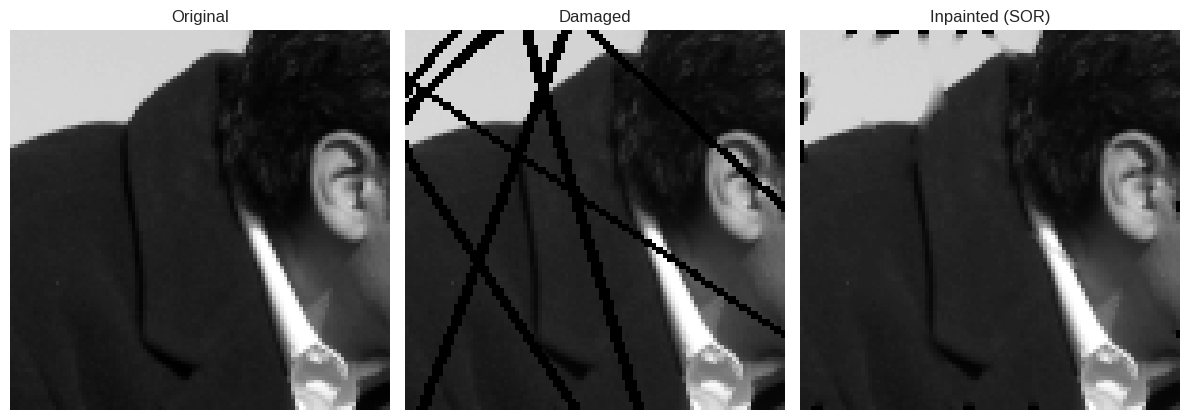

In [12]:
plt.figure(figsize=(12,5))

plt.subplot(1,3,1)
plt.imshow(img, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(damaged, cmap="gray")
plt.title("Damaged")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(inpainted, cmap="gray")
plt.title("Inpainted (SOR)")
plt.axis("off")

plt.tight_layout()
plt.show()

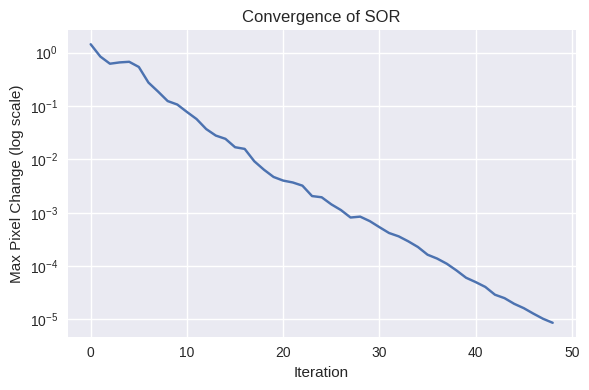

In [13]:
plt.figure(figsize=(6,4))
plot_history = np.asarray(history, dtype=float)
plot_history = np.maximum(plot_history, 1e-12)
plt.plot(plot_history)
plt.yscale("log")
plt.title("Convergence of SOR")
plt.xlabel("Iteration")
plt.ylabel("Max Pixel Change (log scale)")
plt.tight_layout()
os.makedirs("../results", exist_ok=True)
plt.savefig("../results/convergence.png", dpi=150)
plt.show()
plt.close()

In [14]:


plt.imsave("./original.png", img, cmap="gray")
plt.imsave("./damaged.png", damaged, cmap="gray")
plt.imsave("./inpainted.png", inpainted, cmap="gray")

---
## Summary & Observations

### Mathematical Summary

| Concept | Formula | Key condition |
|---------|---------|---------------|
| Matrix splitting | $A = M - N$ | $M$ invertible and cheap |
| Fixed-point iteration | $\mathbf{u}^{(k+1)} = T\mathbf{u}^{(k)} + \mathbf{c}$ | $T = M^{-1}N$ |
| Error propagation | $\mathbf{e}^{(k)} = T^k \mathbf{e}^{(0)}$ | Geometric decay |
| Convergence criterion | $\rho(T) < 1$ | Necessary & sufficient |
| Jacobi splitting | $M_J = D$ | Simplest but slowest |
| Gauss-Seidel splitting | $M_{GS} = D - L$ | $\approx 2\times$ Jacobi |
| SOR update | $(1-\omega)u^{(k)} + \omega\tilde{u}^{(k+1)}_{GS}$ | $\omega \in (0,2)$ required |
| SOR convergence | $\rho(T_\omega) < 1$ | Guaranteed for SPD + $(0,2)$ |
| Kahan's theorem | $0 < \omega < 2$ | Hard necessary condition |
| Optimal $\omega$ | $\omega^* = \frac{2}{1+\sqrt{1-\rho_J^2}}$ | $O(n)$ vs $O(n^2)$ for GS |

### Practical Observations

- **Reconstruction quality:** The damaged region is filled with a smooth harmonic extension that blends naturally with the intact pixels — exactly what $\nabla^2 u = 0$ guarantees.
- **SOR acceleration:** With $\omega = 1.7$ the solver converges noticeably faster than pure Gauss-Seidel ($\omega = 1$), consistent with the $O(n)$ vs $O(n^2)$ theory.
- **Limitation — smoothing:** The Laplacian penalises all curvature equally, so high-frequency textures (edges, fine detail) are **not** recovered inside the mask. More advanced inpainting (e.g., TV inpainting, PDE-based anisotropic diffusion, or deep learning) is needed to preserve texture.
- **Log-scale convergence plot:** The straight-line decay on the log scale confirms the theoretical geometric convergence $\|e^{(k)}\| \sim C \cdot \rho^k$.

---
*This notebook demonstrates that classical numerical PDE methods, grounded in rigorous linear algebra theory, remain directly applicable to modern image processing problems.*
